## Modelo Preditivo de Adesão para Campanha Mercado Crédito
#### O objetivo é prever se um cliente vai aderir ("yes" ou "no") a um novo produto do Mercado Crédito

### Bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Modelagem (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Configurações de Visualização e Avisos
%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### Carregar e Inspecionar Dados

In [4]:
file_path = 'MeliDataset.csv'

df = pd.read_csv(file_path, sep=';')
print(f"Arquivo '{file_path}' carregado com sucesso.")

print("\nPrimeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais
print("\nInformações do DataFrame:")
df.info()

# Exibe estatísticas descritivas (numéricas)
print("\nEstatísticas Descritivas (Variáveis Numéricas):")
print(df.describe(include=np.number))

Arquivo 'MeliDataset.csv' carregado com sucesso.

Primeiras 5 linhas do DataFrame:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  no

In [ ]:
Bloco 3: Verificar Valores 'unknown'

In [5]:
print("\nContagem de valores 'unknown' por coluna categórica:")
for col in df.select_dtypes(include='object').columns:
    unknown_count = df[col].value_counts().get('unknown', 0)
    if unknown_count > 0:
        print(f"- {col}: {unknown_count} 'unknown' values")


Contagem de valores 'unknown' por coluna categórica:
- job: 330 'unknown' values
- marital: 80 'unknown' values
- education: 1731 'unknown' values
- default: 8597 'unknown' values
- housing: 990 'unknown' values
- loan: 990 'unknown' values


### Limpeza e Identificação de Features

In [6]:
# 1. Converter a variável alvo 'y' para binário (0 e 1)
df['y'] = df['y'].map({'no': 0, 'yes': 1})
print(f"\nDistribuição da variável alvo 'y' após conversão:\n{df['y'].value_counts(normalize=True)}")

# 2. Remover a coluna 'duration'
df = df.drop('duration', axis=1)
print("\nColuna 'duration' removida.")

# 3. Identificar tipos de colunas para pré-processamento
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('y') # Remove a variável alvo da lista de features numéricas

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nColunas Numéricas (Features): {numerical_cols}")
print(f"Colunas Categóricas: {categorical_cols}")

# 4. Tratamento de 'unknown': Será tratado como categoria pelo OneHotEncoder.
print("\nTratamento de 'unknown': Será tratado como uma categoria separada.")


Distribuição da variável alvo 'y' após conversão:
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Coluna 'duration' removida.

Colunas Numéricas (Features): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Colunas Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Tratamento de 'unknown': Será tratado como uma categoria separada.


### EDA - Análise da Variável Alvo

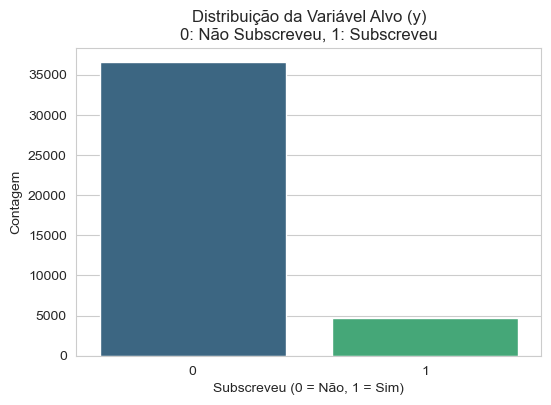

Proporção:
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribuição da Variável Alvo (y)\n0: Não Subscreveu, 1: Subscreveu')
plt.xlabel("Subscreveu (0 = Não, 1 = Sim)")
plt.ylabel("Contagem")
plt.show()
print(f"Proporção:\n{df['y'].value_counts(normalize=True)}")

### EDA - Análise de Variáveis Numéricas


Distribuição das Variáveis Numéricas:


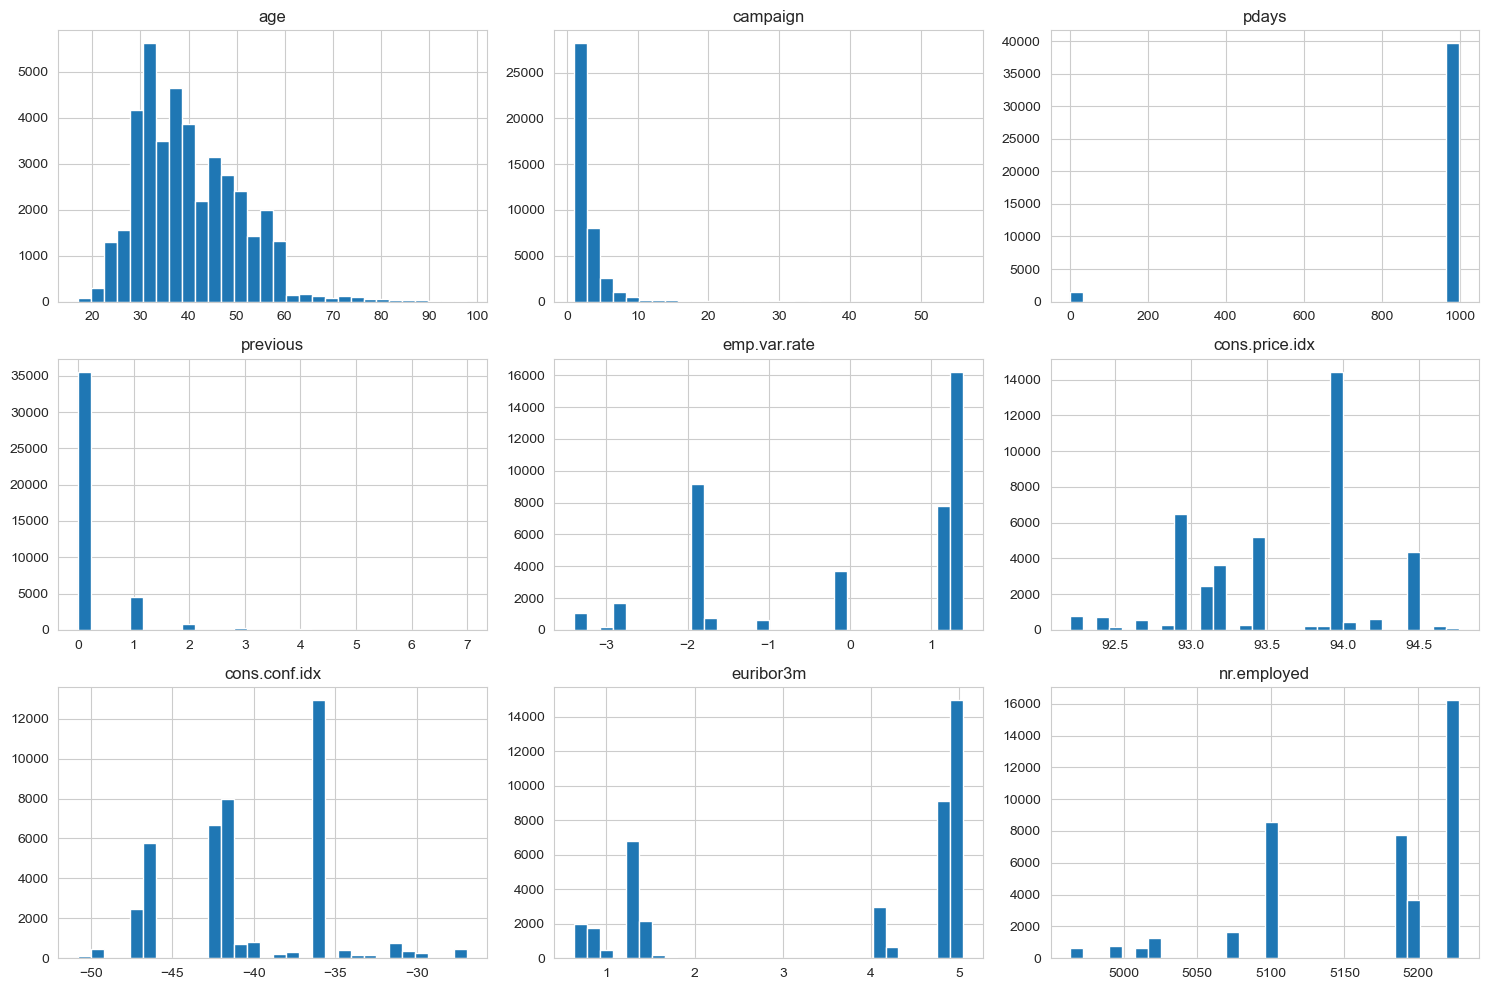


Boxplots das Variáveis Numéricas vs Variável Alvo (y):


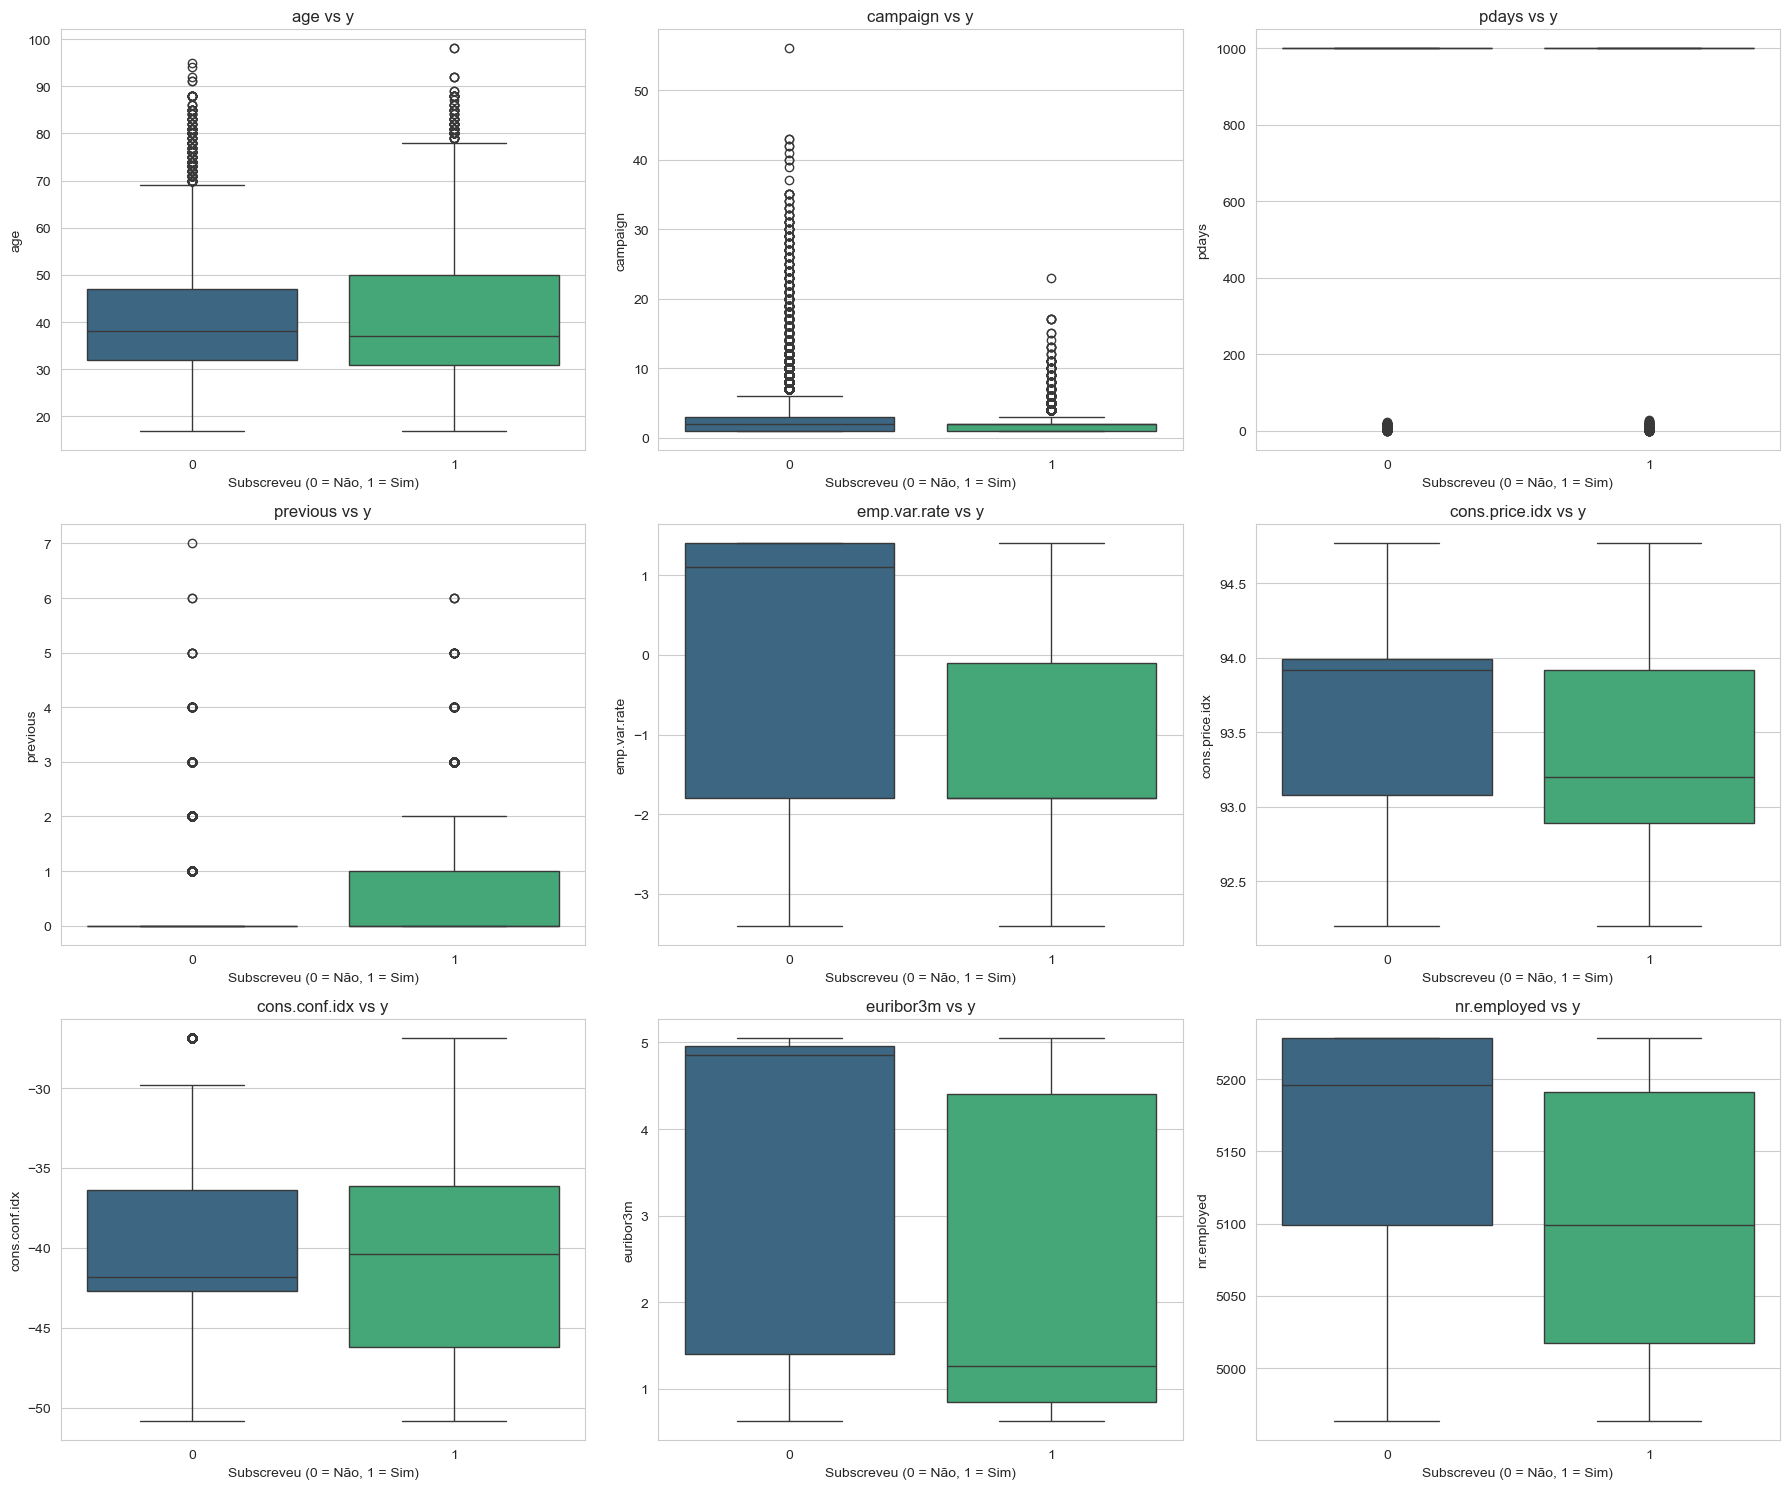

In [8]:
print("\nDistribuição das Variáveis Numéricas:")
df[numerical_cols].hist(bins=30, figsize=(15, 10), layout=(-1, 3)) # Ajusta layout
plt.tight_layout()
plt.show()

print("\nBoxplots das Variáveis Numéricas vs Variável Alvo (y):")
n_cols_plot = 3
n_rows_plot = (len(numerical_cols) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(nrows=n_rows_plot, ncols=n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs y')
    axes[i].set_xlabel("Subscreveu (0 = Não, 1 = Sim)")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### EDA - Análise de Variáveis Categóricas


Distribuição das Variáveis Categóricas:


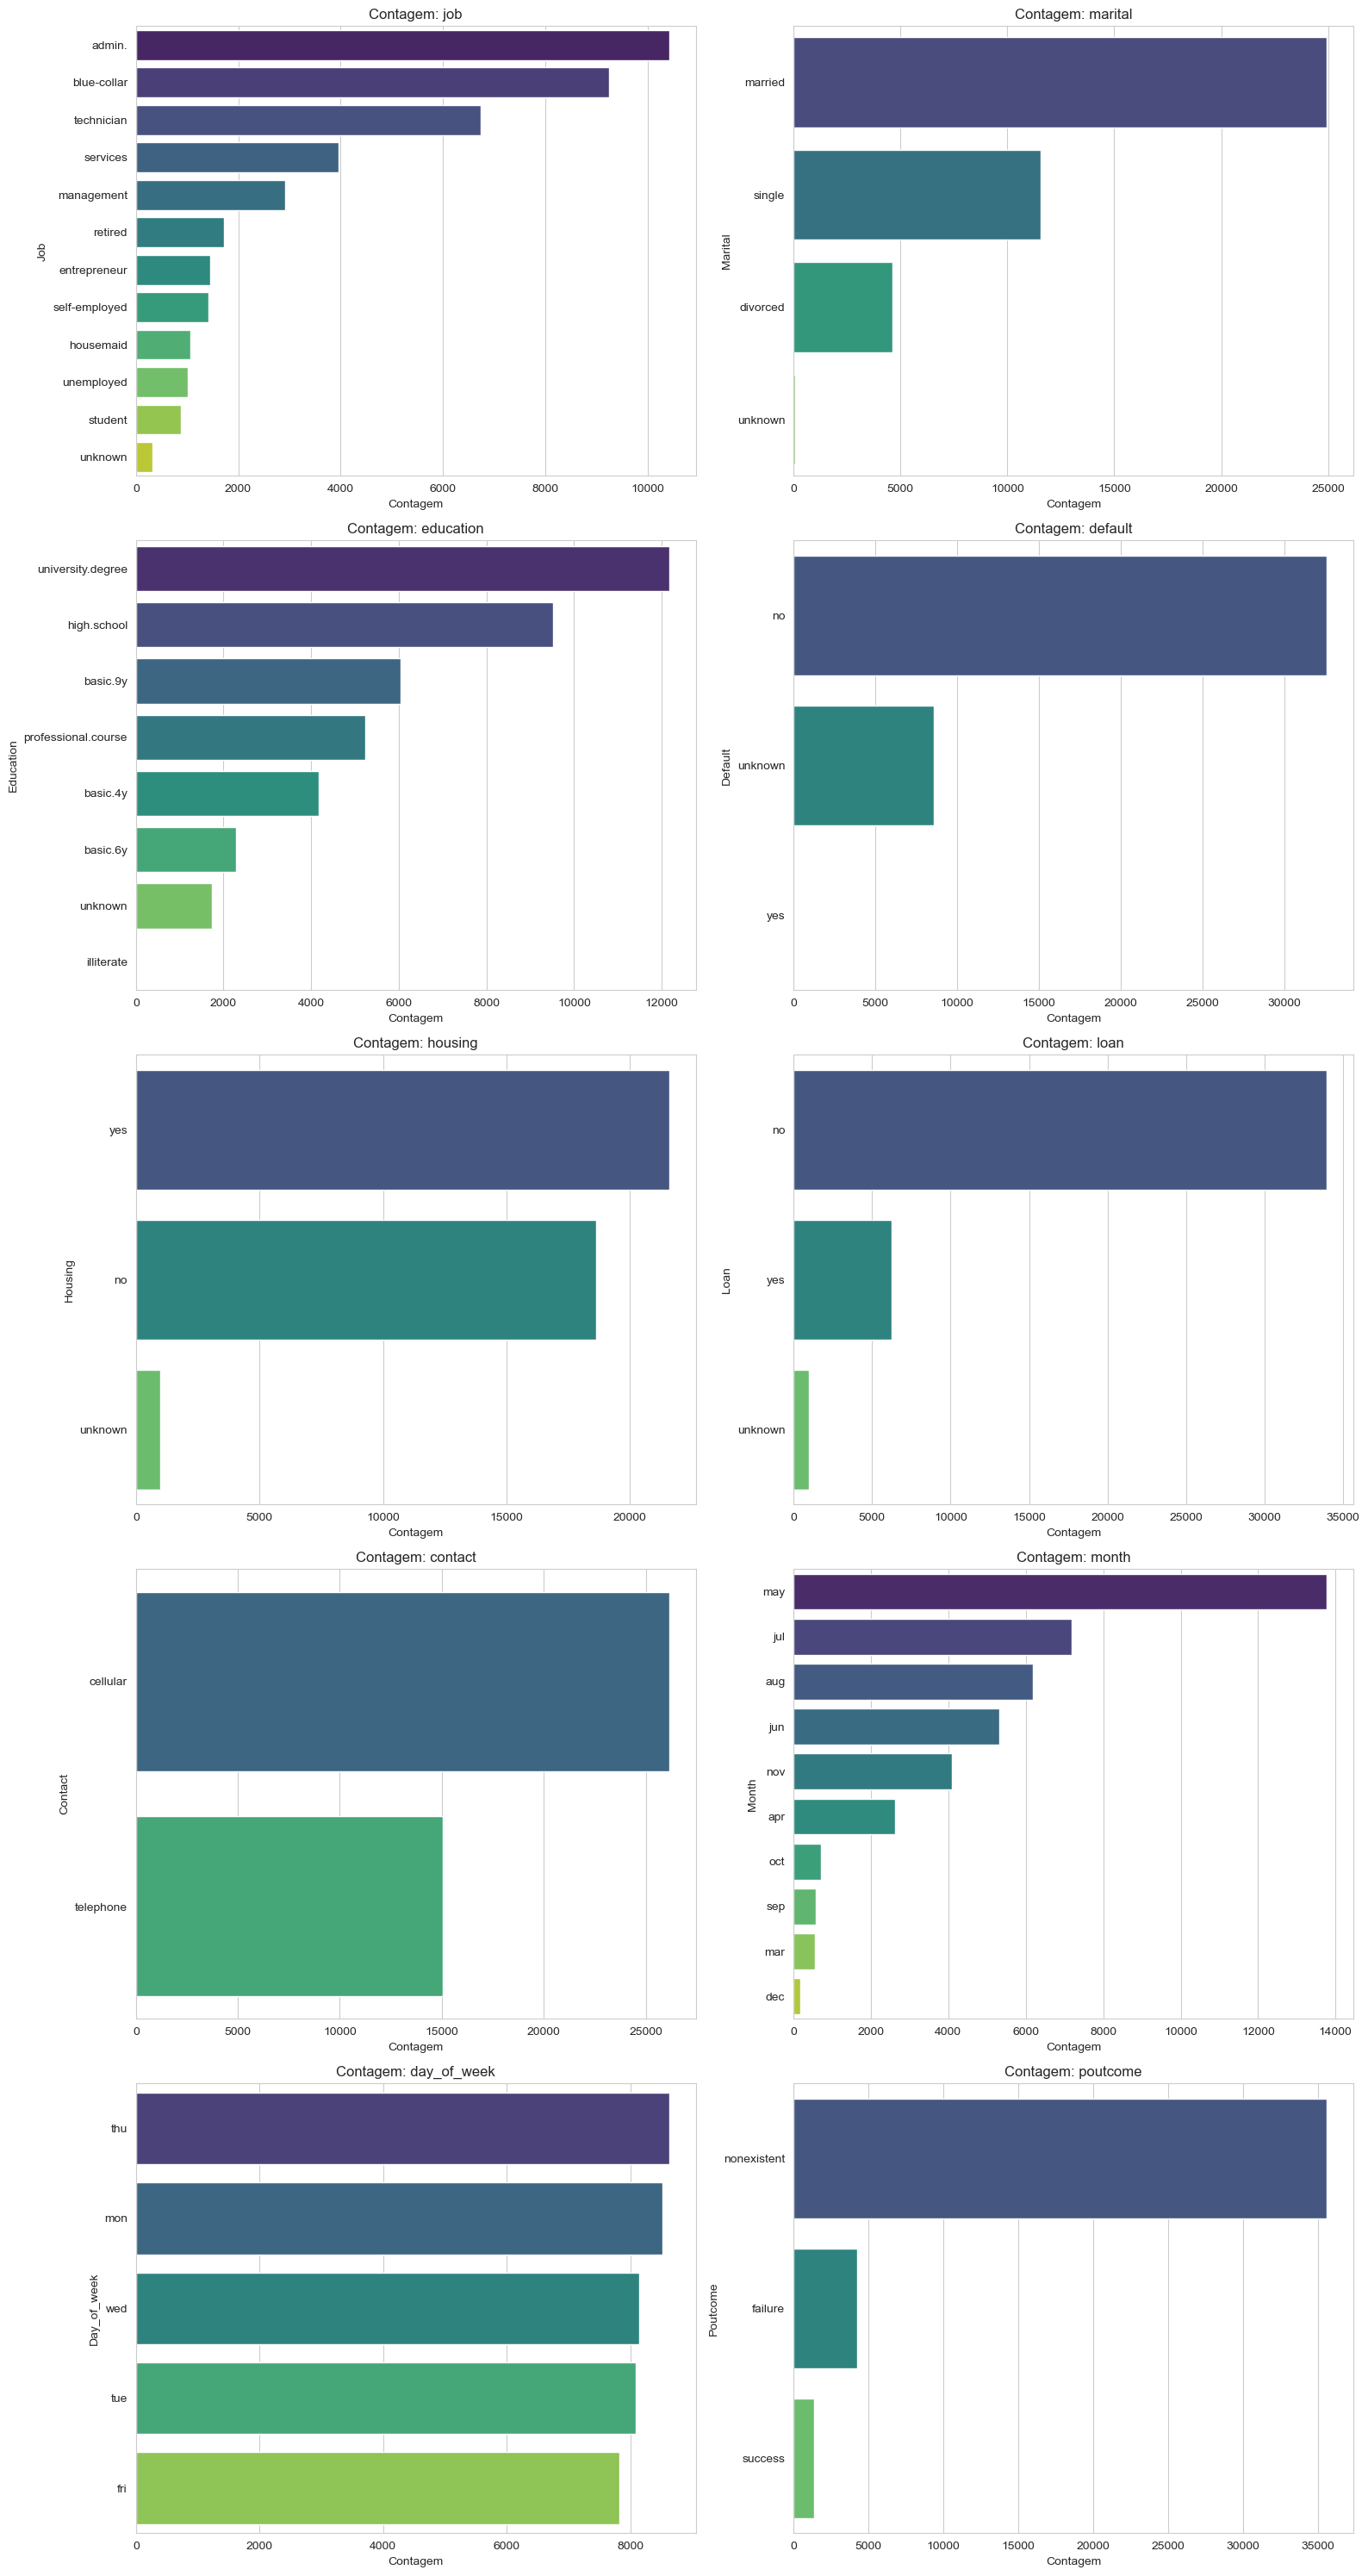


Relação das Variáveis Categóricas vs Variável Alvo (y):


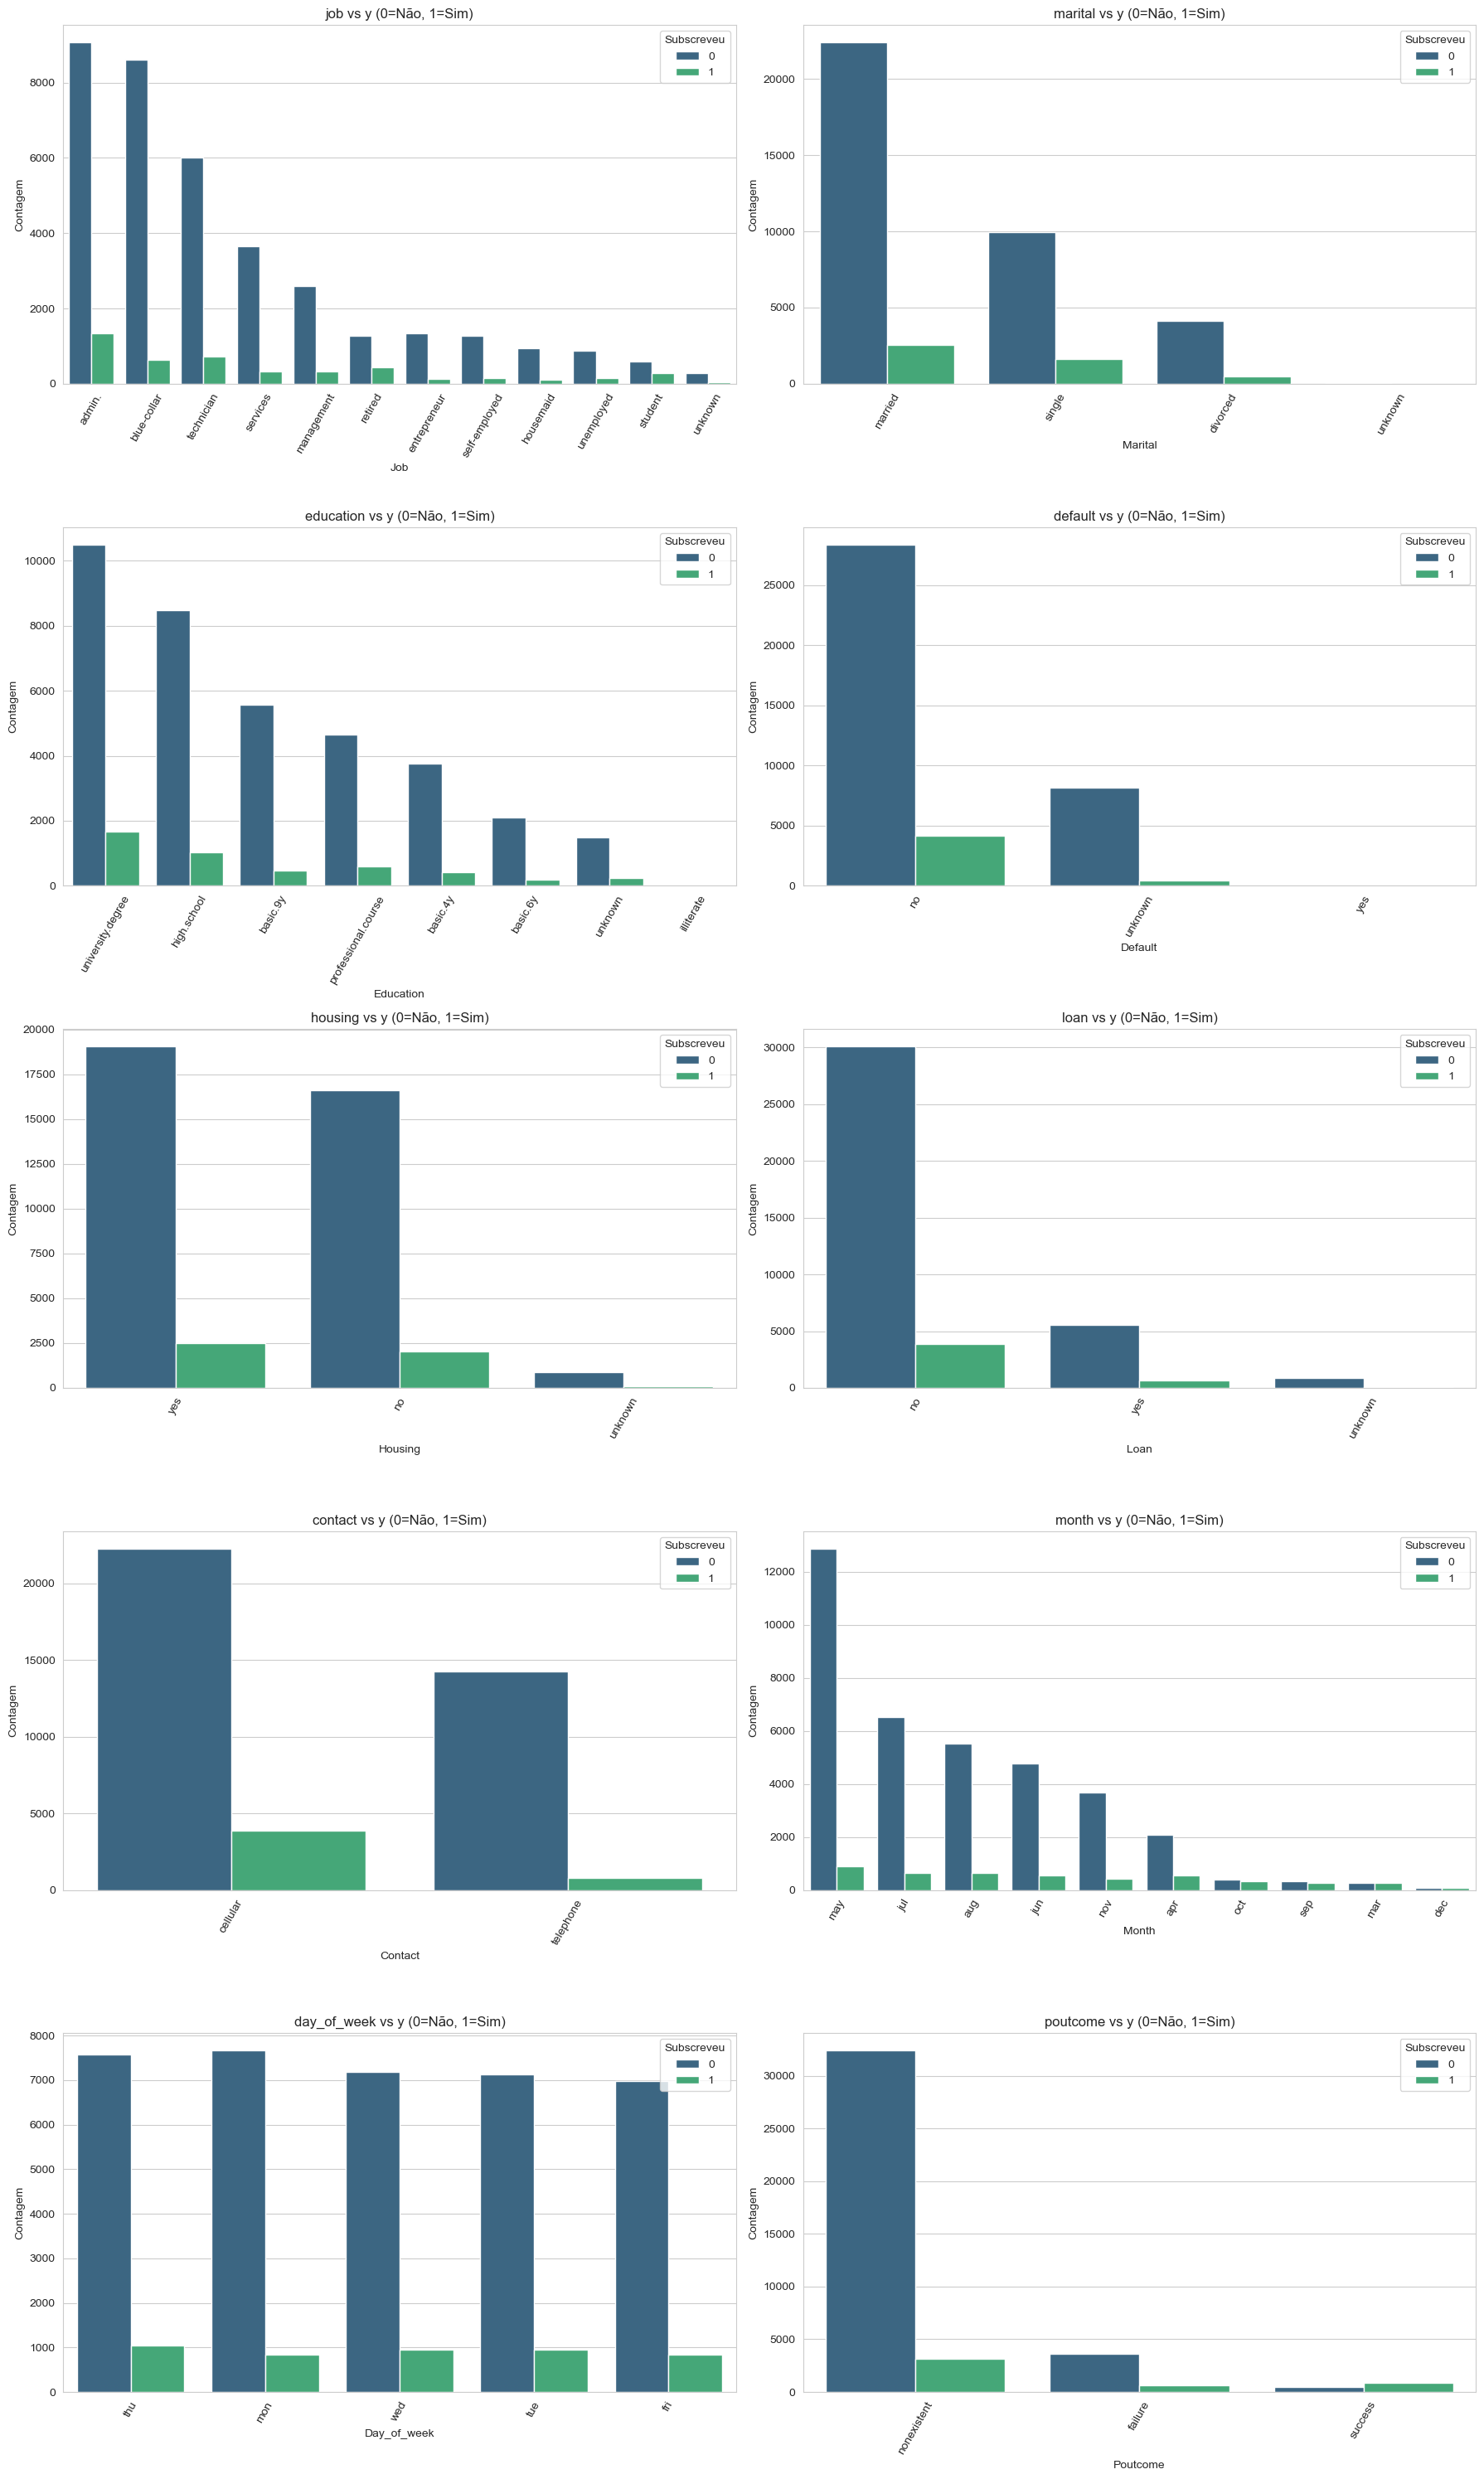

In [9]:
print("\nDistribuição das Variáveis Categóricas:")
n_cols_plot_cat = 2
n_rows_plot_cat = (len(categorical_cols) + n_cols_plot_cat - 1) // n_cols_plot_cat
fig, axes = plt.subplots(nrows=n_rows_plot_cat, ncols=n_cols_plot_cat, figsize=(16, 6 * n_rows_plot_cat)) # Ajustado tamanho
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'Contagem: {col}')
    axes[i].set_xlabel("Contagem")
    axes[i].set_ylabel(col.capitalize())
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

print("\nRelação das Variáveis Categóricas vs Variável Alvo (y):")
fig, axes = plt.subplots(nrows=n_rows_plot_cat, ncols=n_cols_plot_cat, figsize=(18, 6 * n_rows_plot_cat))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue='y', data=df, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'{col} vs y (0=Não, 1=Sim)')
    axes[i].tick_params(axis='x', rotation=60)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Contagem")
    axes[i].legend(title='Subscreveu')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
Bloco 8: EDA - Matriz de Correlação (Numéricas)


Matriz de Correlação entre Variáveis Numéricas (incluindo alvo 'y'):


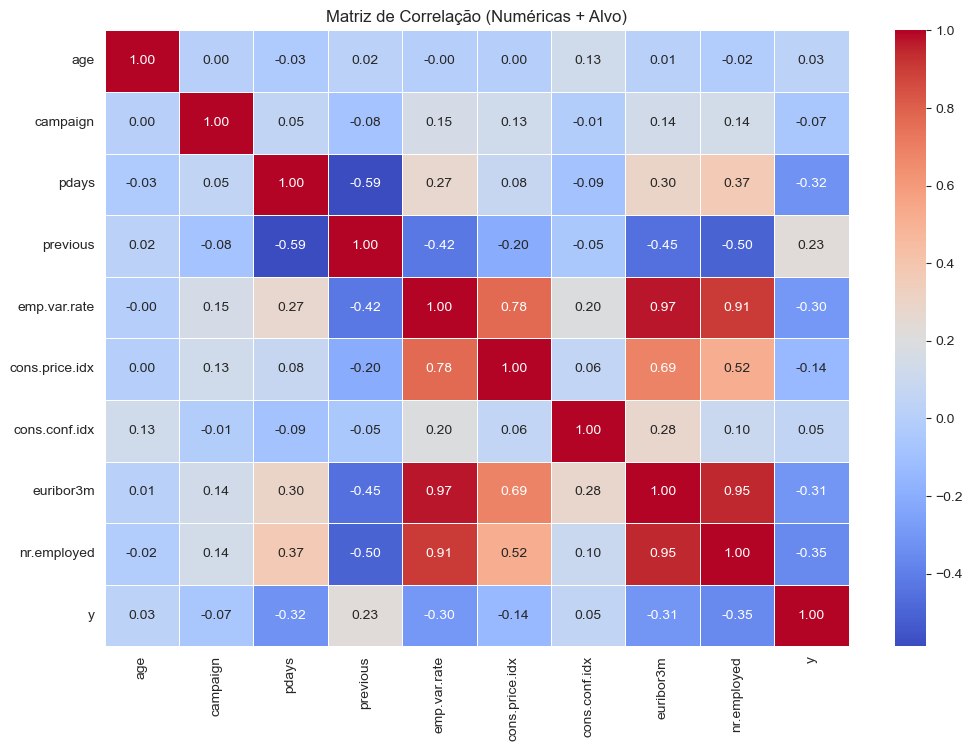

In [10]:
print("\nMatriz de Correlação entre Variáveis Numéricas (incluindo alvo 'y'):")
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols + ['y']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação (Numéricas + Alvo)')
plt.show()

### Divisão em Conjuntos de Treino e Teste

In [11]:
# Separar features (X) e variável alvo (y)
X = df.drop('y', axis=1)
y = df['y']

# Dividir em treino e teste (80% treino, 20% teste) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de Treino: {X_train.shape}, {y_train.shape}")
print(f"Tamanho do conjunto de Teste: {X_test.shape}, {y_test.shape}")
print(f"\nProporção da classe alvo no Treino:\n{y_train.value_counts(normalize=True)}")
print(f"\nProporção da classe alvo no Teste:\n{y_test.value_counts(normalize=True)}")

Tamanho do conjunto de Treino: (32950, 19), (32950,)
Tamanho do conjunto de Teste: (8238, 19), (8238,)

Proporção da classe alvo no Treino:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Proporção da classe alvo no Teste:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### Criação do Pipeline de Pré-processamento

In [12]:
# Recriar listas de colunas baseadas em X_train (boa prática após split)
numerical_cols_train = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols_train = X_train.select_dtypes(include='object').columns.tolist()

# Criar o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_train),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols_train)
    ],
    remainder='passthrough' # Manter colunas inesperadas (se houver) - idealmente não deveria haver
)

print("Pipeline de pré-processamento criado.")
print("Colunas numéricas a serem escaladas:", numerical_cols_train)
print("Colunas categóricas a serem codificadas:", categorical_cols_train)

Pipeline de pré-processamento criado.
Colunas numéricas a serem escaladas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Colunas categóricas a serem codificadas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Criação dos Pipelines Completos (Pré-processamento + Modelo)

In [13]:
# --- Modelo 1: Regressão Logística (Baseline) ---
pipeline_lr = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

# --- Modelo 2: Random Forest ---
pipeline_rf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)) # n_jobs=-1 usa todos os cores
])

print("Pipelines de modelos (LR e RF) criados.")

Pipelines de modelos (LR e RF) criados.


### Treinamento e Avaliação dos Modelos


--- Avaliando: Regressão Logística ---
Acurácia: 0.8350
AUC-ROC: 0.8009

Matriz de Confusão:


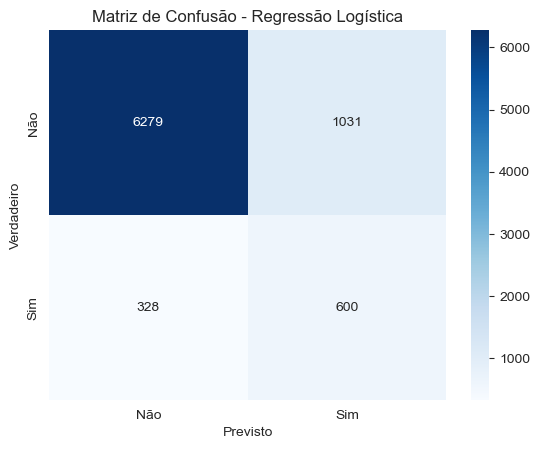


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238


--- Avaliando: Random Forest ---
Acurácia: 0.8957
AUC-ROC: 0.7817

Matriz de Confusão:


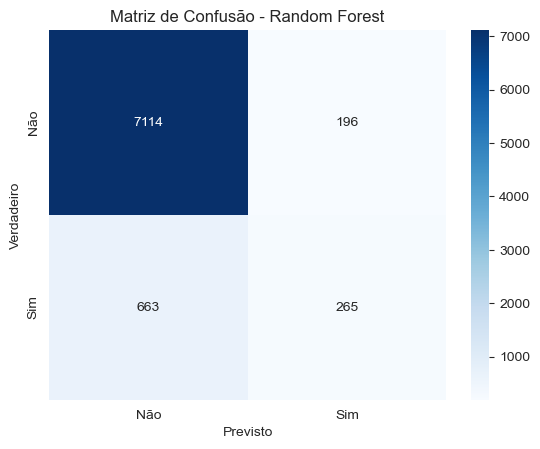


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.57      0.29      0.38       928

    accuracy                           0.90      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



In [14]:
# --- Avaliar Regressão Logística ---
print("\n" + "="*30)
print("--- Avaliando: Regressão Logística ---")
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr)

print(f"Acurácia: {accuracy_lr:.4f}")
print(f"AUC-ROC: {roc_auc_lr:.4f}")
print("\nMatriz de Confusão:")
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Não', 'Sim'], yticklabels=['Não', 'Sim'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()
print("\nRelatório de Classificação:")
print(report_lr)
print("="*30)


# --- Avaliar Random Forest ---
print("\n" + "="*30)
print("--- Avaliando: Random Forest ---")
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Acurácia: {accuracy_rf:.4f}")
print(f"AUC-ROC: {roc_auc_rf:.4f}")
print("\nMatriz de Confusão:")
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Não', 'Sim'], yticklabels=['Não', 'Sim'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest')
plt.show()
print("\nRelatório de Classificação:")
print(report_rf)
print("="*30)

### Análise de Feature Importance (Random Forest)


--- Análise de Feature Importance (Random Forest) ---


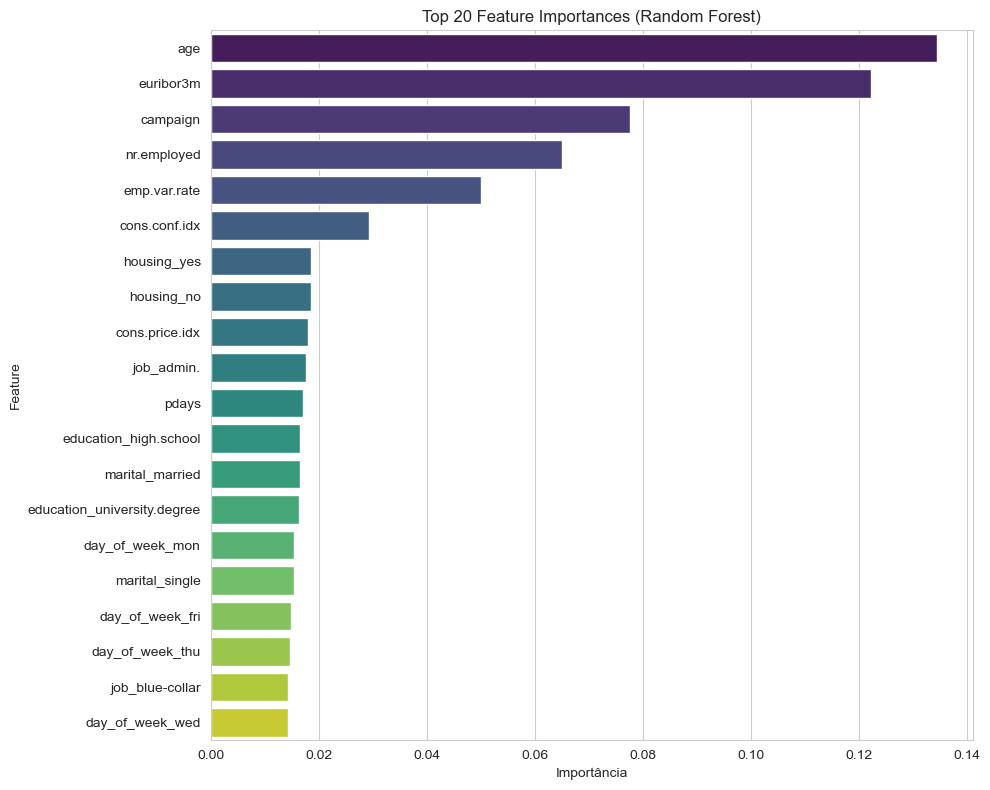


Top 20 Features mais importantes:
                        Feature  Importance
0                           age    0.134476
7                     euribor3m    0.122232
1                      campaign    0.077603
8                   nr.employed    0.065061
4                  emp.var.rate    0.050051
6                 cons.conf.idx    0.029274
38                  housing_yes    0.018684
36                   housing_no    0.018646
5                cons.price.idx    0.018002
9                    job_admin.    0.017610
2                         pdays    0.017103
28        education_high.school    0.016626
22              marital_married    0.016528
31  education_university.degree    0.016316
55              day_of_week_mon    0.015538
23               marital_single    0.015468
54              day_of_week_fri    0.014821
56              day_of_week_thu    0.014799
10              job_blue-collar    0.014439
58              day_of_week_wed    0.014357


In [15]:
print("\n--- Análise de Feature Importance (Random Forest) ---")

# Acessar o pré-processador e o modelo treinados
preprocessor_fitted = pipeline_rf.named_steps['preprocess']
rf_model = pipeline_rf.named_steps['classifier']

# Obter nomes das features após o OneHotEncoding
try:
    # Acessa o transformador OneHotEncoder dentro do ColumnTransformer
    ohe_transformer = preprocessor_fitted.named_transformers_['cat']
    # Obtém os nomes das features categóricas originais que foram codificadas
    ohe_feature_names = ohe_transformer.get_feature_names_out(categorical_cols_train)

    # Combina nomes das features numéricas com as novas features categóricas
    # (Assume que 'remainder' é 'passthrough' e não há outras colunas)
    all_feature_names = numerical_cols_train + list(ohe_feature_names)

    # Obter importâncias
    importances = rf_model.feature_importances_

    # Criar DataFrame
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Visualizar Top N features
    N = 20
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(N), palette='viridis')
    plt.title(f'Top {N} Feature Importances (Random Forest)')
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print(f"\nTop {N} Features mais importantes:")
    print(feature_importance_df.head(N))

except Exception as e:
    print(f"Erro ao obter/visualizar Feature Importance: {e}")
    print("Verifique se os nomes dos transformadores ('cat', 'num') estão corretos no ColumnTransformer.")

### Análise de Erros (Random Forest)

In [16]:
print("\n--- Análise de Erros (Random Forest) ---")

# Identificar índices de erros no conjunto de teste original (X_test)
false_positives_idx = X_test[(y_test == 0) & (y_pred_rf == 1)].index
false_negatives_idx = X_test[(y_test == 1) & (y_pred_rf == 0)].index

# Selecionar as instâncias correspondentes de X_test
false_positives = X_test.loc[false_positives_idx]
false_negatives = X_test.loc[false_negatives_idx]

print(f"\nNúmero de Falsos Positivos (Previsto 1, Verdadeiro 0): {len(false_positives)}")
print(f"Número de Falsos Negativos (Previsto 0, Verdadeiro 1): {len(false_negatives)}")

# Exibir exemplos de erros
print("\n--- Exemplos de Falsos Negativos (Modelo previu 'Não', mas era 'Sim') ---")
print(false_negatives.head())

print("\n--- Exemplos de Falsos Positivos (Modelo previu 'Sim', mas era 'Não') ---")
print(false_positives.head())


--- Análise de Erros (Random Forest) ---

Número de Falsos Positivos (Previsto 1, Verdadeiro 0): 196
Número de Falsos Negativos (Previsto 0, Verdadeiro 1): 663

--- Exemplos de Falsos Negativos (Modelo previu 'Não', mas era 'Sim') ---
       age          job   marital          education default housing loan  \
38884   68      retired   married        high.school      no      no   no   
28008   30       admin.   married  university.degree      no     yes  yes   
16326   38   technician   married        high.school      no     yes   no   
26933   34       admin.  divorced  university.degree      no      no   no   
37582   29  blue-collar    single           basic.6y      no      no   no   

        contact month day_of_week  campaign  pdays  previous     poutcome  \
38884  cellular   nov         mon         2    999         1      failure   
28008  cellular   apr         thu         2    999         0  nonexistent   
16326  cellular   jul         tue         8    999         0  nonexist

### Tratamento dos dados Desbalanceados
(Reamostragem com SMOTE (Oversampling)

In [17]:
# Importar SMOTE e Pipeline do imblearn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

### Criar e Avaliar Pipeline com SMOTE (usando Random Forest)


--- Avaliando: Random Forest com SMOTE ---
Acurácia: 0.8894
AUC-ROC: 0.7803

Matriz de Confusão:


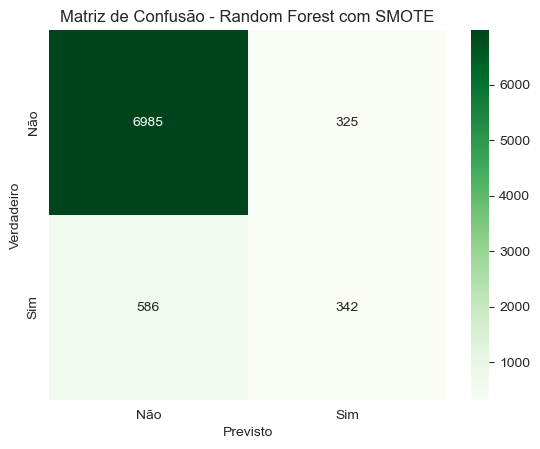


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.51      0.37      0.43       928

    accuracy                           0.89      8238
   macro avg       0.72      0.66      0.68      8238
weighted avg       0.88      0.89      0.88      8238



In [18]:
# Cria um novo pipeline usando o Pipeline do imbalanced-learn
pipeline_rf_smote = ImbPipeline([
    ('preprocess', preprocessor), 
    ('smote', SMOTE(random_state=42)), # Aplica SMOTE antes do classificador
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # RF sem class_weight agora
])

print("\n" + "="*30)
print("--- Avaliando: Random Forest com SMOTE ---")

# Treinar o pipeline completo (pré-processamento + SMOTE + RF)
pipeline_rf_smote.fit(X_train, y_train)

# Fazer previsões no conjunto de teste (SMOTE não é aplicado aqui!)
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_pred_proba_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:, 1]

# Avaliar
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
roc_auc_rf_smote = roc_auc_score(y_test, y_pred_proba_rf_smote)
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
report_rf_smote = classification_report(y_test, y_pred_rf_smote)

print(f"Acurácia: {accuracy_rf_smote:.4f}")
print(f"AUC-ROC: {roc_auc_rf_smote:.4f}")
print("\nMatriz de Confusão:")
sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Greens', xticklabels=['Não', 'Sim'], yticklabels=['Não', 'Sim']) # Mudei a cor
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest com SMOTE')
plt.show()
print("\nRelatório de Classificação:")
print(report_rf_smote)
print("="*30)

### Abordagem com GridSearch


--- Iniciando Otimização de Hiperparâmetros (GridSearchCV) ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
--- Otimização Concluída ---

Melhores Parâmetros Encontrados:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150, 'smote__k_neighbors': 5}

--- Avaliando: Melhor Modelo RF com SMOTE (Otimizado) ---
Acurácia (Otimizado): 0.8755
AUC-ROC (Otimizado): 0.8094

Matriz de Confusão (Otimizado):


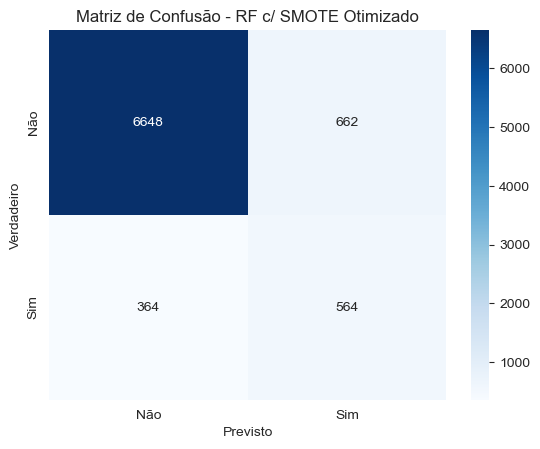


Relatório de Classificação (Otimizado):
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.46      0.61      0.52       928

    accuracy                           0.88      8238
   macro avg       0.70      0.76      0.73      8238
weighted avg       0.89      0.88      0.88      8238



In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score, f1_score

# Mesmo Pipeline de Antes.
pipeline_rf_smote_opt = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Definir o espaço de parâmetros para testar
param_grid = {
    'smote__k_neighbors': [3, 5, 7], # Parâmetro do SMOTE
    'classifier__n_estimators': [100, 150], # Número de árvores
    'classifier__max_depth': [10, 20, None], # Profundidade máxima
    'classifier__min_samples_leaf': [3, 5], # Mínimo de amostras por folha
}

# Configurar o GridSearchCV
scoring = {
    'AUC': 'roc_auc',
    'Recall_1': make_scorer(recall_score, pos_label=1),
    'F1_1': make_scorer(f1_score, pos_label=1)
}


# Usaremos F1 da classe 1 como principal para refit
grid_search = GridSearchCV(pipeline_rf_smote_opt, param_grid,
                           scoring=scoring, # Avalia várias métricas
                           refit='F1_1', # Otimiza para o F1 da classe 1
                           cv=3, # 3-fold cross-validation (aumente se tiver tempo/recursos)
                           n_jobs=-1, # Usar todos os processadores
                           verbose=2) # Mostra o progresso

print("\n" + "="*30)
print("--- Iniciando Otimização de Hiperparâmetros (GridSearchCV) ---")
# Treinar com GridSearchCV
grid_search.fit(X_train, y_train)
print("--- Otimização Concluída ---")

# Melhor pipeline encontrado
best_pipeline = grid_search.best_estimator_
print(f"\nMelhores Parâmetros Encontrados:\n{grid_search.best_params_}")

# Avaliar o melhor modelo no conjunto de teste
y_pred_best = best_pipeline.predict(X_test)
y_pred_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

# Avaliar o modelo otimizado
print("\n" + "="*30)
print("--- Avaliando: Melhor Modelo RF com SMOTE (Otimizado) ---")
accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
cm_best = confusion_matrix(y_test, y_pred_best)
report_best = classification_report(y_test, y_pred_best)

print(f"Acurácia (Otimizado): {accuracy_best:.4f}")
print(f"AUC-ROC (Otimizado): {roc_auc_best:.4f}")
print("\nMatriz de Confusão (Otimizado):")
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['Não', 'Sim'], yticklabels=['Não', 'Sim'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - RF c/ SMOTE Otimizado')
plt.show()
print("\nRelatório de Classificação (Otimizado):")
print(report_best)
print("="*30)

# Conclusões Finais

## 1. Metodologia e Fases Executadas

Seguimos as fases clássicas de um projeto de Machine Learning:

* **Tratamento do Desbalanceamento e Otimização (Experimentação):**
    * **Tentativa 1:** Aplicamos a técnica de oversampling SMOTE no pipeline do Random Forest. Isso resultou em uma melhora no Recall (para 0.37), mas ainda baixo, e uma queda na Precisão.
    * **Tentativa 2:** Realizamos uma otimização de hiperparâmetros (`GridSearchCV`) no pipeline Random Forest + SMOTE, focando em maximizar o F1-Score da classe minoritária. Esta abordagem se mostrou a mais promissora..

## 3. Análise do Modelo Final Selecionado

Com base nos experimentos, selecionamos o modelo Random Forest otimizado com SMOTE.

**Melhores Hiperparâmetros Encontrados:**
`{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150, 'smote__k_neighbors': 5}`

**Métricas de Avaliação no Conjunto de Teste:**

* **AUC-ROC:** 0.8094
* **Acurácia Geral:** 0.8755
* **Classe 1 ('yes' - Aderiu):**
    * **Recall:** 0.61
    * **Precision:** 0.46
    * **F1-Score:** 0.52
* **Classe 0 ('no' - Não aderiu):**
    * Recall: 0.91
    * Precision: 0.95
    * F1-Score: 0.93